# Exploración inicial de la telemetría

Primer contacto con FastF1 antes de escribir el pipeline de ingesta. El objetivo
acá no es producir nada reutilizable, sino contestar tres preguntas:

1. ¿Qué devuelve realmente la API y con qué estructura?
2. ¿Qué canales llegan por vuelta y a qué frecuencia?
3. ¿El cache local sirve para no depender de la red en cada corrida?

Todo lo que se valida en este notebook termina codificado en `src/ingesta_carreras.py`.
Se trabaja sobre Silverstone 2024 como caso de referencia: es un circuito largo,
de carrera seca y con la grilla completa, así que no esconde casos raros.


## 1. Qué trae una sesión

Antes de pedir telemetría conviene ver el listado de pilotos y el resultado final.
Sirve para detectar el caso que más adelante obliga a un chequeo explícito en la
ingesta: pilotos que aparecen en los resultados pero no tienen vueltas parseadas.

La sesión se carga sin telemetría ni clima: alcanza con los resultados y es varios
órdenes de magnitud más rápido.


In [ ]:
import fastf1

# El cache guarda las respuestas crudas de la API de timing. Sin él, cada
# ejecución vuelve a bajar la sesión entera y tarda minutos.
fastf1.Cache.enable_cache("data/cache/")

s = fastf1.get_session(2024, "Silverstone", "R")

# Se piden solo los resultados: telemetría, clima y mensajes de dirección
# multiplican el tiempo de carga y acá no hacen falta.
s.load(telemetry=False, weather=False, messages=False)

print(s.results[["Abbreviation", "DriverNumber", "Position", "Status"]])

# Contrastar esta lista con la anterior: si un número aparece en los resultados
# pero no acá, FastF1 no pudo parsear sus vueltas.
print(sorted(s.laps["DriverNumber"].unique()))


## 2. Telemetría de una vuelta rápida

Se aísla la vuelta más rápida de un piloto y se grafica velocidad contra distancia.

La vuelta rápida es la referencia natural para comparar: está libre de tráfico y
de gestión de neumático, así que la traza describe el circuito y no la estrategia.
El eje de distancia, y no el de tiempo, es lo que permite superponer dos pilotos
más adelante.


core           INFO 	Loading data for British Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 10)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 20 drivers: ['44', '1', '4', '81', '55', '27', '18', '14', '23', '22', '2', '20', '3', '16', '77', '31', '11', '24', '63', '10']


Data ingested successfully. DataFrame shape: (682, 18)


,Date,SessionTime,DriverAhead,DistanceToDriverAhead,Time,RPM,Speed,nGear,Throttle,Brake,DRS,Source,Distance,RelativeDistance,Status,X,Y,Z
2,2024-07-07 15:18:14.967,0 days 02:13:17.938000,,66.808333,0 days 00:00:00,11515.525000,255.625000,6,100.0,False,0,interpolation,0.052679,0.000009,OnTrack,-1746.572603,1222.620354,1963.152228
3,2024-07-07 15:18:15.072,0 days 02:13:18.043000,,66.808333,0 days 00:00:00.105000,11657.931163,258.906248,6,100.0,False,0,pos,7.624745,0.001314,OnTrack,-1701.000000,1283.000000,1964.000000
4,2024-07-07 15:18:15.075,0 days 02:13:18.046000,,66.808333,0 days 00:00:00.108000,11662.000000,259.000000,6,100.0,False,0,car,7.842222,0.001351,OnTrack,-1699.682956,1284.726135,1964.018621
5,2024-07-07 15:18:15.352,0 days 02:13:18.323000,,66.808333,0 days 00:00:00.385000,10864.949619,263.629528,6,100.0,False,0,pos,28.177308,0.004856,OnTrack,-1575.000000,1444.000000,1965.000000
6,2024-07-07 15:18:15.434,0 days 02:13:18.405000,4,66.808333,0 days 00:00:00.467000,10629.000000,265.000000,6,100.0,False,0,car,34.268611,0.005905,OnTrack,-1537.339638,1490.830998,1965.516355


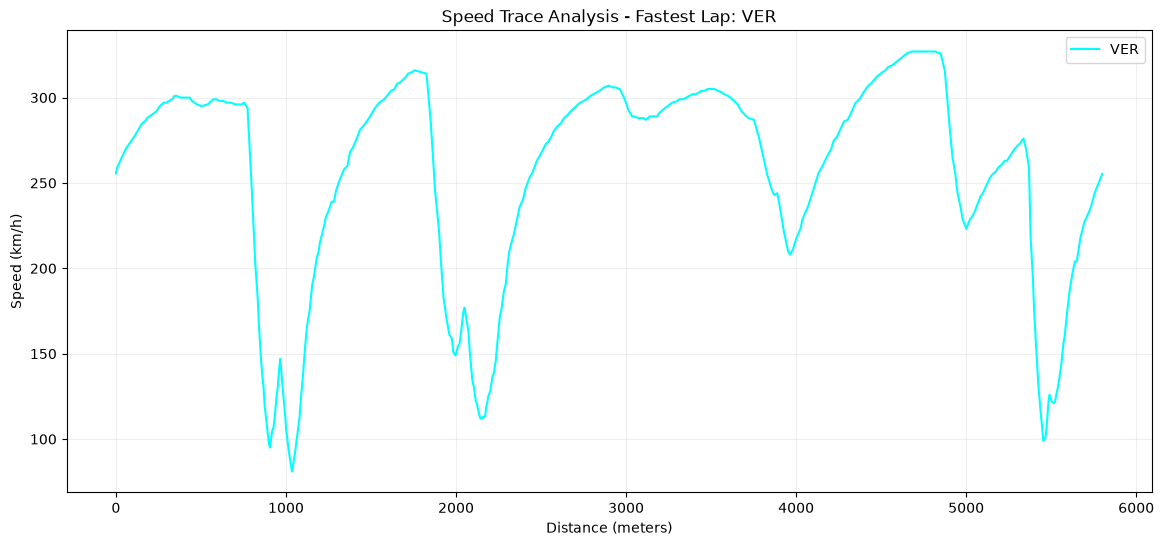

In [5]:
"""
Extracción y graficado de la vuelta rápida de un piloto.

Valida la estructura que devuelve FastF1 y deja armado el patrón que después
usa el pipeline de ingesta: sesión -> vueltas -> telemetría de una vuelta.
"""

import os
import fastf1
import fastf1.plotting
import matplotlib.pyplot as plt
import pandas as pd

# Ruta absoluta: el notebook puede ejecutarse desde la raíz del proyecto o desde
# notebooks/, y una ruta relativa apuntaría a lugares distintos en cada caso.
CACHE_DIR = os.path.abspath("../data/cache/")
if not os.path.exists(CACHE_DIR):
    os.makedirs(CACHE_DIR)

# Reutilizar el cache es lo que hace viable iterar: la segunda corrida de una
# misma sesión no toca la red.
fastf1.Cache.enable_cache(CACHE_DIR)

def fetch_fastest_lap_telemetry(year: int, grand_prix: str, session_type: str, driver_id: str) -> pd.DataFrame:
    """
    Devuelve la telemetría de la vuelta más rápida de un piloto.

    Args:
        year: Temporada del campeonato.
        grand_prix: Nombre o sede del evento ('Silverstone', 'Monza', ...).
        session_type: Tipo de sesión ('FP1', 'FP2', 'FP3', 'Q', 'S', 'R').
        driver_id: Código de tres letras del piloto ('VER', 'HAM', 'LEC', ...).

    Returns:
        DataFrame con los canales de alta frecuencia: Speed, RPM, nGear,
        Throttle, Brake y las coordenadas X, Y, Z.
    """
    session = fastf1.get_session(year, grand_prix, session_type)

    # La telemetría viene incluida por defecto; se descartan clima y mensajes.
    session.load(weather=False, messages=False)

    # La vuelta rápida es la referencia limpia: sin tráfico ni gestión de goma.
    fastest_lap = session.laps.pick_drivers([driver_id]).pick_fastest()

    # get_telemetry() ya interpola los canales a una grilla común y agrega la
    # columna Distance, que arranca en 0 al cruzar la meta.
    telemetry = fastest_lap.get_telemetry()

    return telemetry

def plot_speed_trace(telemetry: pd.DataFrame, driver_id: str):
    """
    Grafica la velocidad contra la distancia recorrida.

    Se usa distancia y no tiempo porque es lo que permite comparar dos vueltas
    distintas: el mismo metro de pista cae siempre en el mismo punto del eje.
    """
    # Aplica el tema oscuro y la paleta de escuderías de FastF1.
    fastf1.plotting.setup_mpl()

    fig, ax = plt.subplots(figsize=(14, 6))

    ax.plot(telemetry['Distance'], telemetry['Speed'], label=driver_id, color='cyan')

    ax.set_xlabel('Distance (meters)')
    ax.set_ylabel('Speed (km/h)')
    ax.set_title(f'Speed Trace Analysis - Fastest Lap: {driver_id}')
    ax.legend()
    ax.grid(alpha=0.2)

    plt.show()

if __name__ == "__main__":
    # Caso de referencia para la validación.
    TARGET_YEAR = 2024
    TARGET_GP = 'Silverstone'
    SESSION = 'R'
    DRIVER = 'VER'

    try:
        df_telemetry = fetch_fastest_lap_telemetry(TARGET_YEAR, TARGET_GP, SESSION, DRIVER)
        print(f"Data ingested successfully. DataFrame shape: {df_telemetry.shape}")

        # Las primeras filas alcanzan para ver qué canales llegan y con qué tipo.
        display(df_telemetry.head())

        plot_speed_trace(df_telemetry, DRIVER)

    except Exception as e:
        print(f"Pipeline execution failed: {e}")


## 3. Comparación entre dos pilotos

Mismo circuito, misma sesión, dos vueltas rápidas superpuestas sobre el eje de
distancia. Los tres paneles compartidos —velocidad, acelerador y freno— muestran
dónde se gana o se pierde el tiempo: un panel solo no alcanza, porque una
diferencia de velocidad en una recta puede venir de una frenada distinta cientos
de metros antes.


core           INFO 	Loading data for British Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 10)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 20 drivers: ['44', '1', '4', '81', '55', '27', '18', '14', '23', '22', '2', '20', '3', '16', '77', '31', '11', '24', '63', '10']
req            INFO 	Using cached data for driver_info


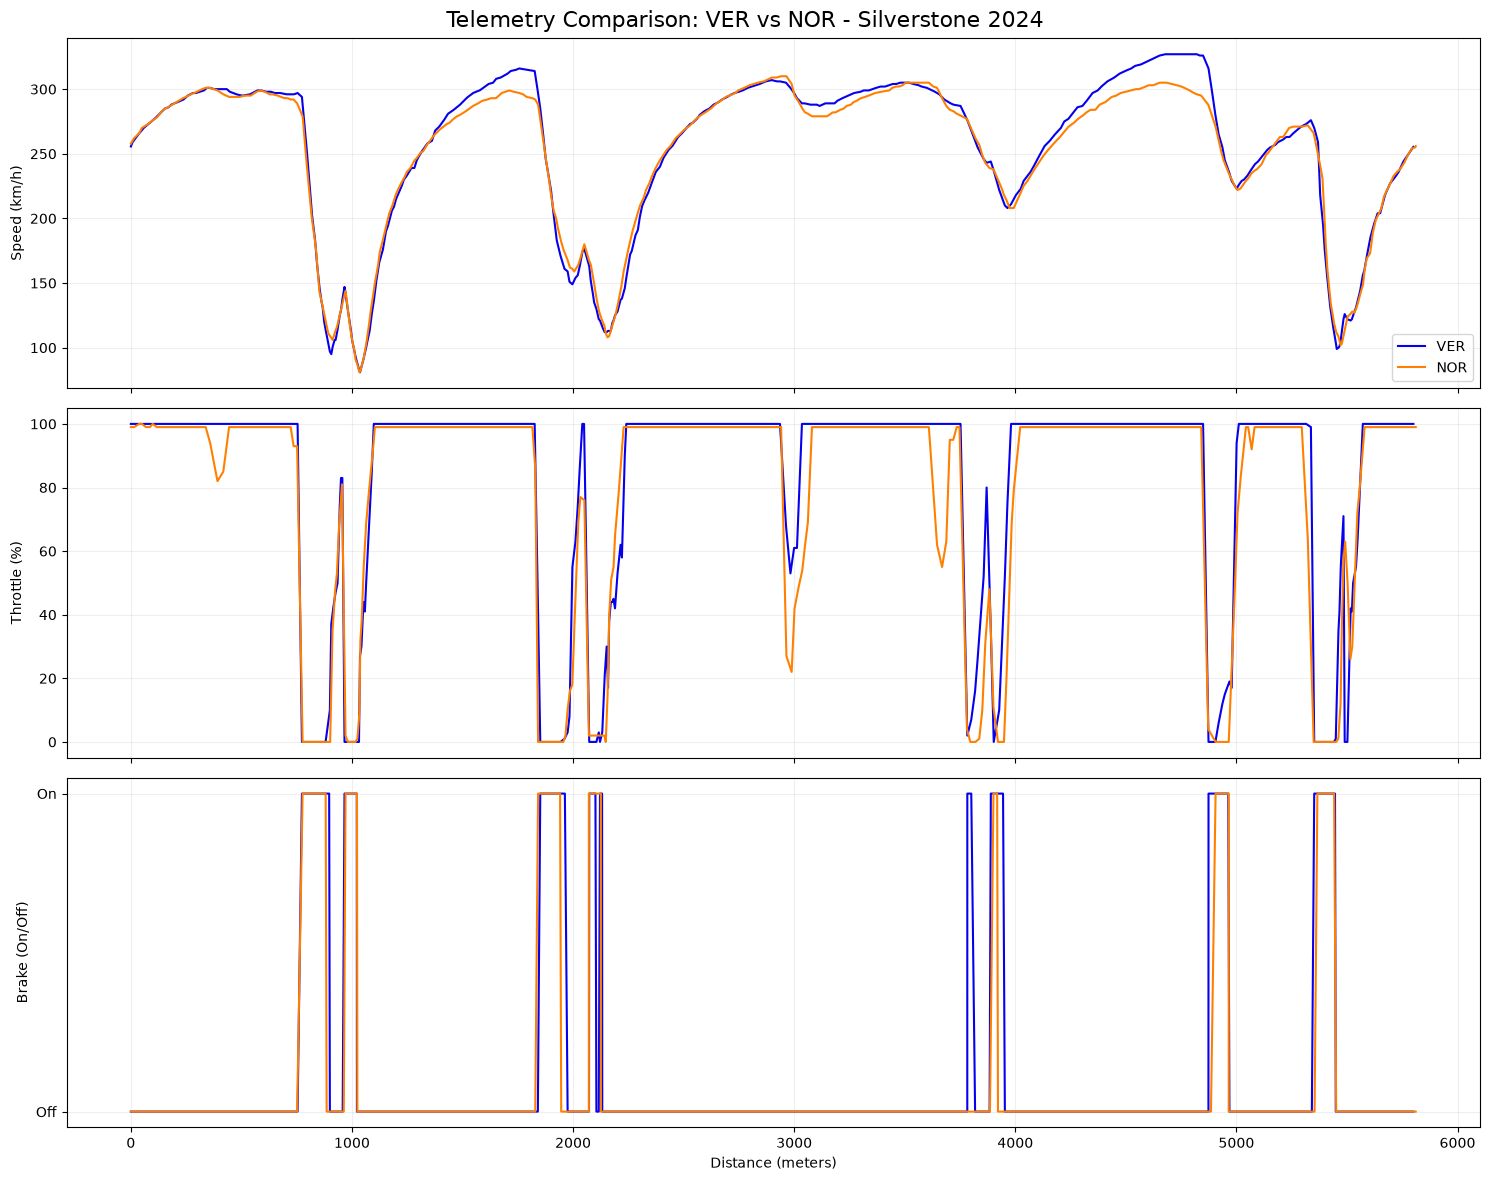

In [7]:
"""
Comparación de telemetría entre dos pilotos.

Superpone velocidad, acelerador y freno de dos vueltas rápidas sobre el mismo
eje de distancia, para ubicar en qué tramos se produce la diferencia de tiempo.
"""

import fastf1
import fastf1.plotting
import matplotlib.pyplot as plt

def plot_head_to_head_telemetry(year: int, grand_prix: str, session_type: str, driver1: str, driver2: str):
    """
    Arma una figura de tres paneles comparando a dos pilotos en su vuelta rápida.

    Args:
        year: Temporada del campeonato.
        grand_prix: Nombre o sede del evento.
        session_type: Tipo de sesión.
        driver1: Código de tres letras del primer piloto.
        driver2: Código de tres letras del segundo piloto.
    """
    session = fastf1.get_session(year, grand_prix, session_type)
    session.load(weather=False, messages=False)
    fastf1.plotting.setup_mpl()

    # Cada piloto aporta su mejor vuelta, no necesariamente de la misma tanda.
    lap_d1 = session.laps.pick_drivers([driver1]).pick_fastest()
    lap_d2 = session.laps.pick_drivers([driver2]).pick_fastest()

    tel_d1 = lap_d1.get_telemetry()
    tel_d2 = lap_d2.get_telemetry()

    # La API de colores cambió de nombre entre versiones de FastF1.
    try:
        # Forma vigente desde la 3.8
        color_d1 = fastf1.plotting.get_team_color(lap_d1['Team'], session=session)
        color_d2 = fastf1.plotting.get_team_color(lap_d2['Team'], session=session)
    except AttributeError:
        # Respaldo fijo para que el notebook corra igual: azul Red Bull y naranja McLaren.
        color_d1 = '#3671C6'
        color_d2 = '#FF8000'

    # sharex: los tres paneles comparten el eje de distancia, así una frenada se
    # lee en la misma vertical en los tres.
    fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
    fig.suptitle(f"Telemetry Comparison: {driver1} vs {driver2} - {grand_prix} {year}", fontsize=16)

    # Panel 1: velocidad. Muestra el resultado, no la causa.
    axes[0].plot(tel_d1['Distance'], tel_d1['Speed'], label=driver1, color=color_d1)
    axes[0].plot(tel_d2['Distance'], tel_d2['Speed'], label=driver2, color=color_d2)
    axes[0].set_ylabel("Speed (km/h)")
    axes[0].legend(loc="lower right")
    axes[0].grid(alpha=0.2)

    # Panel 2: acelerador. Dónde vuelve a pisar cada uno a la salida de curva.
    axes[1].plot(tel_d1['Distance'], tel_d1['Throttle'], label=driver1, color=color_d1)
    axes[1].plot(tel_d2['Distance'], tel_d2['Throttle'], label=driver2, color=color_d2)
    axes[1].set_ylabel("Throttle (%)")
    axes[1].grid(alpha=0.2)

    # Panel 3: freno. Llega como booleano; se pasa a entero solo para graficarlo.
    axes[2].plot(tel_d1['Distance'], tel_d1['Brake'].astype(int), label=driver1, color=color_d1)
    axes[2].plot(tel_d2['Distance'], tel_d2['Brake'].astype(int), label=driver2, color=color_d2)
    axes[2].set_ylabel("Brake (On/Off)")
    axes[2].set_xlabel("Distance (meters)")
    axes[2].set_yticks([0, 1])
    axes[2].set_yticklabels(['Off', 'On'])
    axes[2].grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # Los dos primeros de la carrera: la diferencia entre ellos es de décimas.
    plot_head_to_head_telemetry(2024, 'Silverstone', 'R', 'VER', 'NOR')
